In [17]:
# Importations nécessaires pour l'analyse exploratoire
# Toutes les bibliothèques sont chargées au début pour clarté

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
from dotenv import load_dotenv

# Style graphique cohérent
plt.style.use("seaborn-v0_8")

# Chargement du fichier .env depuis la racine du projet
# Le notebook se trouve dans /notebooks, donc on remonte d'un niveau
env_path = os.path.abspath(os.path.join(os.getcwd(), "..", ".env"))
load_dotenv(env_path)

# Fonction de connexion sécurisée à PostgreSQL
# → aucune information sensible n'est écrite dans le code
# → toutes les variables proviennent du fichier .env
def get_conn():
    return psycopg2.connect(
        dbname=os.getenv("POSTGRES_DB"),      # nom de la base
        user=os.getenv("POSTGRES_USER"),      # utilisateur PostgreSQL
        password=os.getenv("POSTGRES_PASSWORD"),  # mot de passe sécurisé
        host="localhost",                     # hôte local (Docker)
        port="5432"                           # port PostgreSQL
    )

In [18]:
# Chargement de la table trajets avec jointures
# → enrichissement avec les usagers et les véhicules

with get_conn() as conn:
    df_trajets = pd.read_sql_query("""
        SELECT 
            t.trj_id,                         -- identifiant du trajet
            t.date_debut,                     -- début du trajet
            t.date_fin,                       -- fin du trajet
            t.duree_min,                      -- durée en minutes
            t.distance_km,                    -- distance parcourue
            t.montant_eur,                    -- montant facturé
            u.prenom || ' ' || u.nom AS utilisateur,  -- nom complet
            v.veh_id AS vehicule              -- identifiant du véhicule
        FROM trajets t
        JOIN usagers u ON t.usr_id = u.usr_id
        JOIN vehicules v ON t.veh_id = v.veh_id;
    """, conn)

df_trajets.head()

/var/folders/5v/1lp98fgn68ndnq8b76tby9hc0000gn/T/ipykernel_96638/764438145.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_trajets = pd.read_sql_query("""


,trj_id,date_debut,date_fin,duree_min,distance_km,montant_eur,utilisateur,vehicule
0,1,2026-03-29 11:19:36.801226+00:00,2026-03-29 11:26:36.801226+00:00,7.0,2.231453,3.383554,Alice Dubois,26
1,2,2026-04-07 11:19:36.804958+00:00,2026-04-07 11:27:36.804958+00:00,8.0,3.567697,3.147881,Léa Richard,17
2,3,2026-04-06 11:19:36.808863+00:00,2026-04-06 11:33:36.808863+00:00,14.0,2.456444,2.814895,Alice Dubois,25
3,4,2026-03-30 11:19:36.811993+00:00,2026-03-30 11:27:36.811993+00:00,8.0,4.417334,2.193779,Alice Dubois,17
4,5,2026-04-02 11:19:36.813993+00:00,2026-04-02 11:29:36.813993+00:00,10.0,2.927206,4.114506,Alice Martin,20


In [19]:
# Chargement de la table usagers
with get_conn() as conn:
    df_usagers = pd.read_sql_query("SELECT * FROM usagers;", conn)

df_usagers.head()

/var/folders/5v/1lp98fgn68ndnq8b76tby9hc0000gn/T/ipykernel_96638/182922363.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_usagers = pd.read_sql_query("SELECT * FROM usagers;", conn)


,usr_id,nom,prenom,email,telephone,type_abonnement,date_inscription,email_hash,telephone_chiffre
0,2,Robert,Alice,user2@example.com,0602,occasionnel,2026-04-07 11:19:36.781490+00:00,2b3b2b9ce842ab8b6a6c614cb1f9604bb8a0d502d1af49...,"[b'\xc3', b'\r', b'\x04', b'\x07', b'\x03', b'..."
1,3,Bernard,Louis,user3@example.com,0603,occasionnel,2026-04-07 11:19:36.781491+00:00,898628e28890f937bdf009391def42879c401a4bcf1b5f...,"[b'\xc3', b'\r', b'\x04', b'\x07', b'\x03', b'..."
2,4,Richard,Léa,user4@example.com,0604,annuel,2026-04-07 11:19:36.781491+00:00,40d71d3f998c168e7a254e75c0a1020185cfc67ab52790...,"[b'\xc3', b'\r', b'\x04', b'\x07', b'\x03', b'..."
3,5,Bernard,Hugo,user5@example.com,0605,occasionnel,2026-04-07 11:19:36.781491+00:00,4d8f4dd97e0c7b6fed6367bed08adc1fe2c7f6d22fc76f...,"[b'\xc3', b'\r', b'\x04', b'\x07', b'\x03', b'..."
4,6,Dubois,Alice,user6@example.com,0606,mensuel,2026-04-07 11:19:36.781491+00:00,b430419a8a3fa1ce5cafd92d89fe3e832b39b1f1cab0f3...,"[b'\xc3', b'\r', b'\x04', b'\x07', b'\x03', b'..."


In [20]:
# Chargement de la table vehicules
with get_conn() as conn:
    df_vehicules = pd.read_sql_query("SELECT * FROM vehicules;", conn)

df_vehicules.head()

/var/folders/5v/1lp98fgn68ndnq8b76tby9hc0000gn/T/ipykernel_96638/2258761737.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_vehicules = pd.read_sql_query("SELECT * FROM vehicules;", conn)


,veh_id,type_veh,statut,niveau_batterie,latitude,longitude,station_id,created_at
0,1,trottinette,disponible,66,None,None,2,2026-04-07 11:19:36.787645+00:00
1,2,trottinette,disponible,67,None,None,3,2026-04-07 11:19:36.789520+00:00
2,3,trottinette,disponible,46,None,None,6,2026-04-07 11:19:36.791143+00:00
3,4,trottinette,disponible,54,None,None,6,2026-04-07 11:19:36.791144+00:00
4,5,trottinette,disponible,29,None,None,5,2026-04-07 11:19:36.792780+00:00


In [21]:
# Statistiques descriptives des trajets
df_trajets.describe()

,trj_id,duree_min,distance_km,montant_eur,vehicule
count,50.00000,50.000000,50.000000,50.000000,50.00000
mean,25.50000,12.980000,2.621466,3.036096,17.66000
std,14.57738,6.096135,1.242222,1.143445,9.04323
min,1.00000,5.000000,0.587645,1.006765,2.00000
25%,13.25000,8.000000,1.491571,2.126748,11.00000
50%,25.50000,12.000000,2.578608,3.155117,18.50000
75%,37.75000,18.750000,3.523951,3.749121,26.00000
max,50.00000,25.000000,4.933890,4.936943,30.00000


In [22]:
# Vérification des valeurs manquantes
df_trajets.isnull().sum()

trj_id         0
date_debut     0
date_fin       0
duree_min      0
distance_km    0
montant_eur    0
utilisateur    0
vehicule       0
dtype: int64

In [23]:
# Distribution des véhicules utilisés
df_trajets["vehicule"].value_counts()

vehicule
3     5
29    5
26    4
20    4
17    3
8     3
28    3
13    3
25    2
30    2
19    2
11    2
18    2
22    2
12    1
2     1
5     1
10    1
15    1
16    1
27    1
4     1
Name: count, dtype: int64

In [24]:
# Durée moyenne par utilisateur
df_trajets.groupby("utilisateur")["duree_min"].mean().sort_values(ascending=False)

utilisateur
Lucas Dubois     23.000000
Alice Martin     16.600000
Alice Bernard    15.750000
Louis Bernard    15.000000
Lucas Bernard    14.333333
Léa Dubois       14.333333
Alice Robert     13.500000
Alice Dubois     11.833333
Alice Thomas     11.000000
Léa Richard      11.000000
Emma Bernard     10.000000
Léa Martin        9.333333
Name: duree_min, dtype: float64

/var/folders/5v/1lp98fgn68ndnq8b76tby9hc0000gn/T/ipykernel_96638/3699471910.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_jour = pd.read_sql_query("""


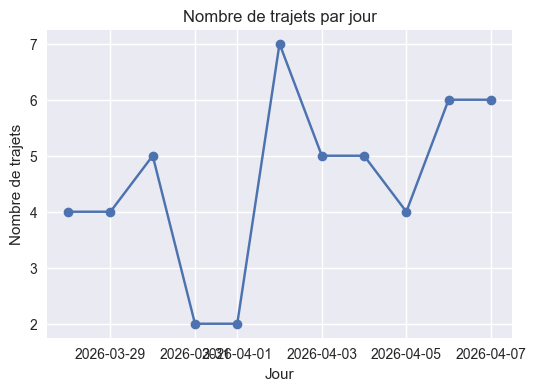

In [25]:
# Nombre de trajets par jour
with get_conn() as conn:
    df_jour = pd.read_sql_query("""
        SELECT DATE(date_debut) AS jour, COUNT(*) AS nb_trajets
        FROM trajets
        GROUP BY jour
        ORDER BY jour;
    """, conn)

plt.figure(figsize=(6,4))
plt.plot(df_jour["jour"], df_jour["nb_trajets"], marker="o")
plt.title("Nombre de trajets par jour")
plt.xlabel("Jour")
plt.ylabel("Nombre de trajets")
plt.grid(True)
plt.show()

/var/folders/5v/1lp98fgn68ndnq8b76tby9hc0000gn/T/ipykernel_96638/446247253.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_duree_user = pd.read_sql_query("""


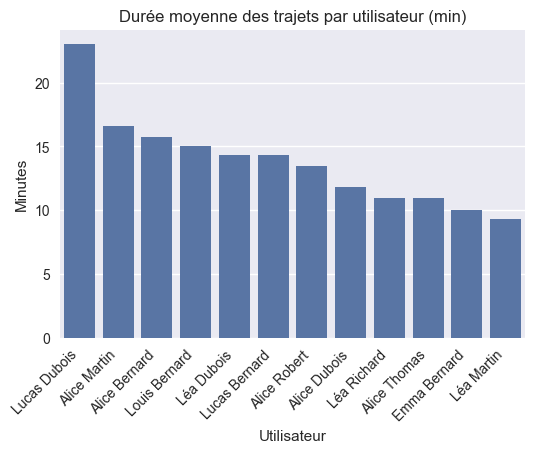

In [26]:
# Durée moyenne par utilisateur
with get_conn() as conn:
    df_duree_user = pd.read_sql_query("""
        SELECT 
            u.prenom || ' ' || u.nom AS utilisateur,
            AVG(t.duree_min) AS duree_moyenne_min
        FROM trajets t
        JOIN usagers u ON t.usr_id = u.usr_id
        GROUP BY utilisateur
        ORDER BY duree_moyenne_min DESC;
    """, conn)

plt.figure(figsize=(6,4))
sns.barplot(data=df_duree_user, x="utilisateur", y="duree_moyenne_min")
plt.title("Durée moyenne des trajets par utilisateur (min)")
plt.ylabel("Minutes")
plt.xlabel("Utilisateur")
plt.xticks(rotation=45, ha="right")
plt.show()

/var/folders/5v/1lp98fgn68ndnq8b76tby9hc0000gn/T/ipykernel_96638/4233915585.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_modele = pd.read_sql_query("""


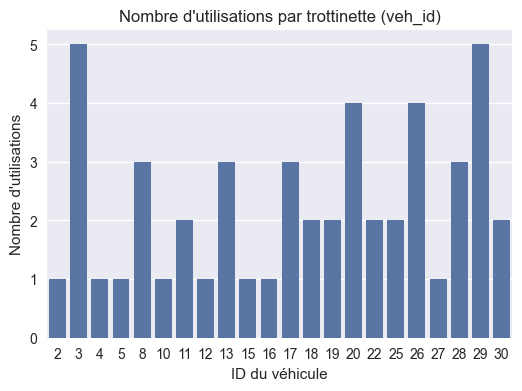

In [27]:
# Utilisation par trottinette (veh_id)
with get_conn() as conn:
    df_modele = pd.read_sql_query("""
        SELECT 
            v.veh_id AS vehicule,
            COUNT(*) AS nb_utilisations
        FROM trajets t
        JOIN vehicules v ON t.veh_id = v.veh_id
        GROUP BY v.veh_id
        ORDER BY nb_utilisations DESC;
    """, conn)

plt.figure(figsize=(6,4))
sns.barplot(data=df_modele, x="vehicule", y="nb_utilisations")
plt.title("Nombre d'utilisations par trottinette (veh_id)")
plt.ylabel("Nombre d'utilisations")
plt.xlabel("ID du véhicule")
plt.show()

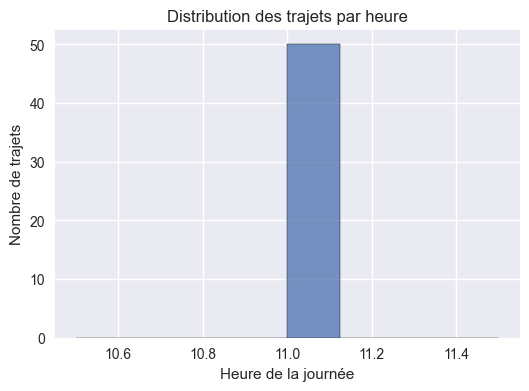

In [28]:
# Distribution des trajets par heure
df_trajets["heure"] = df_trajets["date_debut"].dt.hour

plt.figure(figsize=(6,4))
sns.histplot(df_trajets["heure"], bins=8)
plt.title("Distribution des trajets par heure")
plt.xlabel("Heure de la journée")
plt.ylabel("Nombre de trajets")
plt.show()

In [29]:
# Analyse croisée : activité des stations vs durée moyenne
with get_conn() as conn:
    df_station = pd.read_sql_query("""
        SELECT 
            station_depart,
            COUNT(*) AS nb_trajets,
            AVG(duree_min) AS duree_moyenne
        FROM trajets
        GROUP BY station_depart
        ORDER BY nb_trajets DESC;
    """, conn)

df_station.head()

/var/folders/5v/1lp98fgn68ndnq8b76tby9hc0000gn/T/ipykernel_96638/3602018334.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_station = pd.read_sql_query("""


,station_depart,nb_trajets,duree_moyenne
0,6,9,13.666667
1,7,9,8.333333
2,1,8,13.750000
3,5,8,16.500000
4,3,6,15.500000


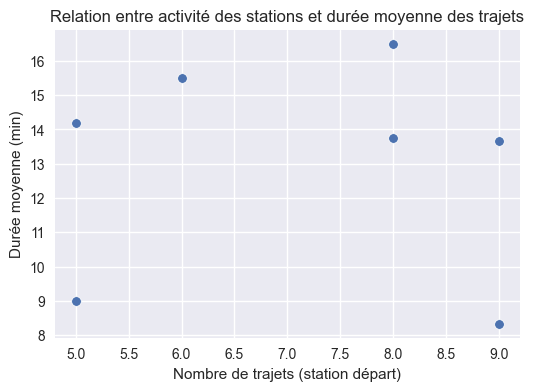

In [30]:
# Visualisation de la relation
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_station, x="nb_trajets", y="duree_moyenne")
plt.title("Relation entre activité des stations et durée moyenne des trajets")
plt.xlabel("Nombre de trajets (station départ)")
plt.ylabel("Durée moyenne (min)")
plt.show()

In [31]:
# Tableau récapitulatif des méthodes pandas utilisées
recap = pd.DataFrame({
    "Concept": [
        "Chargement depuis SQL",
        "Aperçu des données",
        "Statistiques",
        "Valeurs manquantes",
        "Comptage catégories",
        "Agrégation",
        "Jointure pandas",
        "Visualisation"
    ],
    "Méthode pandas": [
        "pd.read_sql_query()",
        ".head() / .shape / .info()",
        ".describe()",
        ".isnull().sum()",
        ".value_counts()",
        ".groupby().agg()",
        ".merge()",
        "matplotlib"
    ],
    "Testé": ["✔"] * 8
})

recap


,Concept,Méthode pandas,Testé
0,Chargement depuis SQL,pd.read_sql_query(),✔
1,Aperçu des données,.head() / .shape / .info(),✔
2,Statistiques,.describe(),✔
3,Valeurs manquantes,.isnull().sum(),✔
4,Comptage catégories,.value_counts(),✔
5,Agrégation,.groupby().agg(),✔
6,Jointure pandas,.merge(),✔
7,Visualisation,matplotlib,✔
